In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..')
sys.path.append('../gen_data/')
from utils import julio
import importlib
# importlib.reload(julio)
import pandas as pd
import src.observables as obs
importlib.reload(obs)
import utils.io as io
from read_corrs import read_corrs, select_dV
import matplotlib as mpl
mpl.style.use('../figmaker/aps.mplstyle')
# import set_size_helper as ssh
# importlib.reload(ssh)

from scipy.fftpack import fft
from matplotlib.lines import Line2D

In [28]:
all_files = []
for N in (64, 128, 256, ):
    for dV in np.arange(3.2, 4.0, 0.05):
        filename = julio.corr_filename_builder(N, 1.0, 0.1, 0.8, dV=dV)
        if os.path.exists(filename):
            all_files.append(filename)
df = julio.load_correlations_files(all_files)
df_i = pd.DataFrame()

idmrg_file_list_dict = {100 : '../../data/iDMRG/rev/scanChi100/corrs/results.h5',
                        200 : '../../data/iDMRG/rev/scanChi200/corrs/results.h5', 
                        400 : '../../data/iDMRG/rev/scanChi200/corrs/results.h5', 
                        800 : '../../data/iDMRG/scanChi800/corrs/results.h5',
                        1000: '../../data/iDMRG/scanChi1000/corrs/results.h5',
                        1200: '../../data/iDMRG/scanChi1200/corrs/results.h5',
}
for chi, idmrg_file in idmrg_file_list_dict.items():
    df_i_chi = read_corrs(idmrg_file)
    df_i_chi['chi'] = chi
    df_i = pd.concat([df_i, df_i_chi])
df.keys(), df_i.keys()

(Index(['szmat', 'chargemat', 'spmmat', 'elecupmat', 'elecdnmat', 'sz_expect',
        'ntot_expect', 'xspin2', 'spin2vec', 'params', 'N', 'dV', 'Vpm',
        'szconn', 'chargeconn', 'spmconn', 'electron_conn', 'filename'],
       dtype='str'),
 Index(['basename', 'src_file', 'dV', 'mean_Sz', 'mean_fill', 'xi',
        'model_params', 'diagnostics', 'charge_corr', 'spinz_corr', 'spsm_corr',
        'electron_corr', 'spin2_corr', 'chi'],
       dtype='str'))

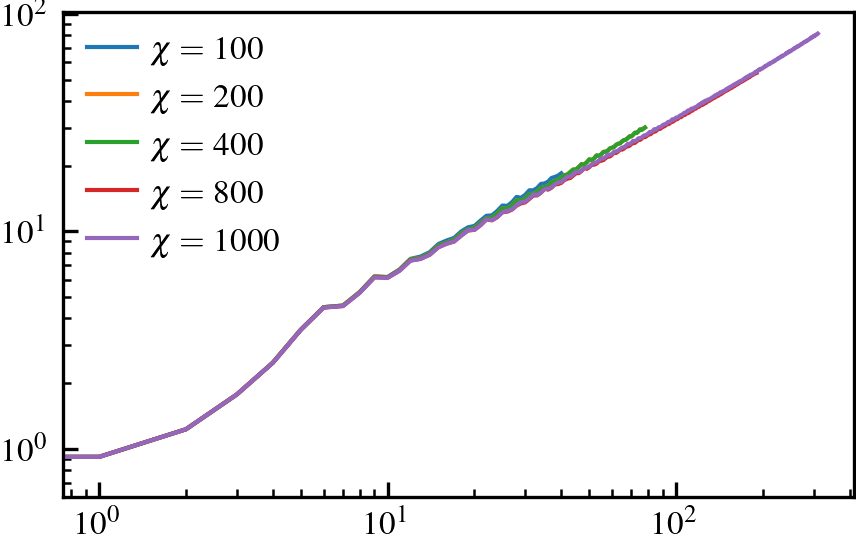

In [42]:
chilist = (100, 200, 400, 800, 1000)
for chi in chilist : 
    seldf_i = df_i[df_i['chi']==chi]
    try : 
        elec_corr = obs.denoise_rolling(np.abs(select_dV(seldf_i, 3.55)['electron_corr']), window=4)
    except :
        print(f"Eror for chi = {chi}")
    rvals = np.arange(len(elec_corr))
    logy = -np.log(elec_corr)
    plt.loglog(rvals, logy, label=rf'$\chi = {{{chi}}}$')
plt.legend()

In [96]:
def fit_succ(x, y, start=0, end=-1, minwin=10):
    if end < 0 : 
        end = len(x) + end
    minm, maxm = 1000., 0.
    minidx = (0,0)
    maxidx = (end, end)
    for ts in range(start, end-minwin):
        for wsize in range(minwin, end-ts):
            fs = slice(ts, ts + wsize)
            m, logc = np.polyfit(x[fs], y[fs], 1)
            if m > maxm: 
                maxm = m
                maxidx = (ts, ts+wsize)
            if m < minm:
                minm = m 
                minidx = (ts, ts+wsize)
    results = (minm, maxm, minidx, maxidx)
    return results

def fit_accum(x, y, start=0, end=-1, winlen=10, covtol=1.):
    if end < 0 : 
        end = len(x) + end
    mlist = []
    startlist = []
    for ts in range(start, end-winlen-1):
            fs = slice(ts, ts + winlen)
            fit, cov = np.polyfit(x[fs], y[fs], 1, cov=True)
            if cov[0,0]*cov[1,1] - cov[1,0]*cov[0,1] < covtol:
                mlist.append(fit[0])
                startlist.append(ts)
    return mlist, startlist




0.6485962031663488 1.0237546947570044 (122, 132) (1, 11)


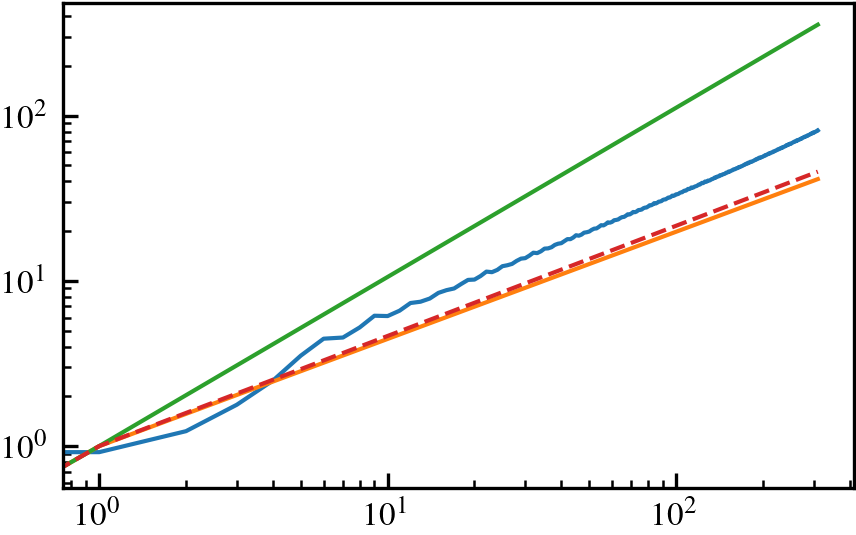

In [88]:
minm, maxm, minidx, maxidx = fit_succ(np.log(rvals[1:]), np.log(logy[1:]), minwin=10)
plt.loglog(rvals, logy)
plt.loglog(rvals, rvals**minm)
plt.loglog(rvals, rvals**maxm)
plt.loglog(rvals, rvals**(2/3), ls='--')
print(minm, maxm, minidx, maxidx)

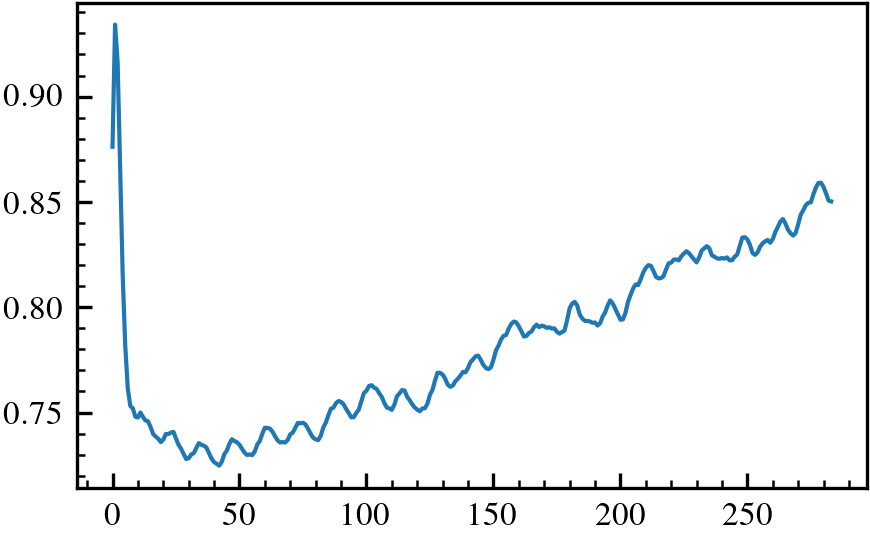

In [109]:
mlist, startlist = fit_accum(np.log(rvals[1:]), obs.denoise_rolling(np.log(logy[1:]), window=4), winlen=24, covtol=1e-5)
plt.plot(startlist, mlist)